*WESAD DATASET*

In [2]:
!pip install -q kagglehub neurokit2 xgboost pywavelets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 708.4/708.4 kB 30.0 MB/s eta 0:00:00


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_auc_score
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

import xgboost as xgb
import kagglehub
import neurokit2 as nk
from scipy.signal import find_peaks
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (8, 4)
RNG = 42
np.random.seed(RNG)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


def plot_cm(y_true, y_pred, labels=None, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels if labels else "auto",
        yticklabels=labels if labels else "auto",
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()


Using device: cuda


In [4]:
# ------------------------------------------------------------
# CELL B1: Download WESAD and detect dataset path
# ------------------------------------------------------------
wesad_root = kagglehub.dataset_download(
    "orvile/wesad-wearable-stress-affect-detection-dataset"
)

print("WESAD root:", wesad_root)
print("Root contents:", os.listdir(wesad_root))

# Some versions contain a "WESAD" subfolder
if "WESAD" in os.listdir(wesad_root):
    DATA_PATH = os.path.join(wesad_root, "WESAD")
else:
    DATA_PATH = wesad_root

print("Using DATA_PATH:", DATA_PATH)
print("Contents:", os.listdir(DATA_PATH))

# Collect subject folders
subject_dirs = [
    d for d in os.listdir(DATA_PATH)
    if os.path.isdir(os.path.join(DATA_PATH, d)) and d.startswith("S")
]

# Remove S1 (missing) & S12 (corrupted)
SUBJECT_IDS = sorted([s for s in subject_dirs if s not in ["S1", "S12"]])
print("Subjects included:", SUBJECT_IDS)

# Constants
ECG_FS = 700
WINDOW_SIZE_SEC = 120
WINDOW_STEP_SEC = 60
WINDOW_SIZE_SAMPLES = ECG_FS * WINDOW_SIZE_SEC
WINDOW_STEP_SAMPLES = ECG_FS * WINDOW_STEP_SEC

# Original WESAD labels of interest
ORIG_LABELS_OF_INTEREST = [1, 2, 3]  # Baseline, Stress, Amusement
LABEL_MAP_TO_012 = {1:0, 2:1, 3:2}
LABEL_MAP_BACK = {v:k for k,v in LABEL_MAP_TO_012.items()}


Using Colab cache for faster access to the 'wesad-wearable-stress-affect-detection-dataset' dataset.
WESAD root: /kaggle/input/wesad-wearable-stress-affect-detection-dataset
Root contents: ['WESAD']
Using DATA_PATH: /kaggle/input/wesad-wearable-stress-affect-detection-dataset/WESAD
Contents: ['S14', 'S11', 'S13', 'S10', 'S8', 'S5', 'S7', 'S9', 'S15', 'wesad_readme.pdf', 'S2', 'S6', 'S3', 'S4', 'S16', 'S17']
Subjects included: ['S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']


In [5]:
# ------------------------------------------------------------
# CELL B2: Helper functions for feature extraction
# ------------------------------------------------------------
import pickle
from scipy.signal import find_peaks

def majority_label(labels_window, labels_of_interest=ORIG_LABELS_OF_INTEREST):
    if len(labels_window) == 0:
        return None
    labels_window = labels_window.astype(int)
    counts = np.bincount(labels_window)
    for lbl in range(len(counts)):
        if lbl not in labels_of_interest:
            counts[lbl] = 0
    return np.argmax(counts) if counts.sum() > 0 else None


def compute_ecg_features(window_start, window_end, rpeaks_idx, fs=ECG_FS):
    mask = (rpeaks_idx >= window_start) & (rpeaks_idx < window_end)
    peaks = rpeaks_idx[mask] - window_start
    if len(peaks) < 3:
        return None

    rr = np.diff(peaks) / fs  # seconds
    if len(rr) < 2:
        return None

    rr_ms = rr * 1000.0
    mean_rr = rr_ms.mean()
    sdnn = rr_ms.std(ddof=1)
    iqr_rr = np.percentile(rr_ms, 75) - np.percentile(rr_ms, 25)

    # HR
    hr = 60000.0 / rr_ms
    hr_mean = hr.mean()
    hr_std = hr.std(ddof=1)

    # RMSSD, NN50/pNN50
    diff_rr = np.diff(rr_ms)
    rmssd = np.sqrt((diff_rr**2).mean()) if len(diff_rr) > 0 else 0
    nn50 = np.sum(np.abs(diff_rr) > 50)
    pnn50 = nn50 / len(diff_rr) if len(diff_rr) > 0 else 0

    return {
        "ECG_MeanRR": mean_rr,
        "ECG_SDNN": sdnn,
        "ECG_IQR_RR": iqr_rr,
        "ECG_HR_Mean": hr_mean,
        "ECG_HR_Std": hr_std,
        "ECG_RMSSD": rmssd,
        "ECG_NN50": float(nn50),
        "ECG_pNN50": pnn50,
        "ECG_NumBeats": float(len(peaks)),
    }


def compute_basic_stats(window, prefix):
    if len(window) == 0:
        return {f"{prefix}_{s}": np.nan for s in ["Mean","Std","Min","Max"]}
    return {
        f"{prefix}_Mean": float(window.mean()),
        f"{prefix}_Std": float(window.std()),
        f"{prefix}_Min": float(window.min()),
        f"{prefix}_Max": float(window.max()),
    }


def compute_eda_features(eda_signal, start, end):
    w = eda_signal[start:end]
    feats = compute_basic_stats(w, "EDA")
    if len(w) == 0:
        feats["EDA_NumPeaks"] = np.nan
        return feats
    try:
        peaks, _ = find_peaks(w, height=w.mean())
        feats["EDA_NumPeaks"] = float(len(peaks))
    except:
        feats["EDA_NumPeaks"] = np.nan
    return feats


def compute_acc_features(acc_signal, start, end):
    w = acc_signal[start:end]
    mag = np.sqrt((w**2).sum(axis=1)) if w.ndim == 2 else np.abs(w)
    feats = compute_basic_stats(mag, "ACC")
    if len(mag) == 0:
        feats["ACC_RMS"] = np.nan
        feats["ACC_ActivityIndex"] = np.nan
    else:
        feats["ACC_RMS"] = float(np.sqrt((mag**2).mean()))
        feats["ACC_ActivityIndex"] = float(np.var(mag))
    return feats


def compute_temp_features(temp_signal, start, end):
    w = temp_signal[start:end]
    feats = compute_basic_stats(w, "TEMP")
    feats["TEMP_Slope"] = float((w[-1] - w[0]) / max(1, len(w))) if len(w) > 0 else np.nan
    return feats


In [6]:
# ------------------------------------------------------------
# CELL B3: Process one WESAD subject (ECG → R-peaks → windows)
# ------------------------------------------------------------
def process_subject(subject_id):
    print(f"\n=== Processing {subject_id} ===")
    path_pkl = os.path.join(DATA_PATH, subject_id, f"{subject_id}.pkl")

    if not os.path.exists(path_pkl):
        print("Missing file, skipping!")
        return None

    try:
        with open(path_pkl, "rb") as f:
            data = pickle.load(f, encoding="latin1")
    except Exception as e:
        print("Error reading file:", e)
        return None

    try:
        chest = data["signal"]["chest"]
        labels = data["label"]

        ecg = chest["ECG"][:, 0] if chest["ECG"].ndim > 1 else chest["ECG"]
        eda = chest["EDA"]
        acc = chest["ACC"]
        temp = chest["Temp"]

        # Clean ECG
        cleaned_ecg = nk.ecg_clean(ecg, sampling_rate=ECG_FS)

        # Detect R-peaks
        _, rpeaks = nk.ecg_peaks(cleaned_ecg, sampling_rate=ECG_FS)
        rpeaks_idx = rpeaks["ECG_R_Peaks"]

        print("ECG samples:", len(ecg))
        print("Detected R-peaks:", len(rpeaks_idx))

        if len(rpeaks_idx) < 3:
            print("Too few R-peaks, skip subject.")
            return None

        rows = []
        n = len(ecg)

        for start in range(0, n - WINDOW_SIZE_SAMPLES, WINDOW_STEP_SAMPLES):
            end = start + WINDOW_SIZE_SAMPLES

            # Window label
            window_labels = labels[start:end]
            lbl = majority_label(window_labels)
            if lbl is None:
                continue

            # ECG features
            ecg_feats = compute_ecg_features(start, end, rpeaks_idx)
            if ecg_feats is None:
                continue

            row = {}
            row.update(ecg_feats)

            # EDA
            row.update(compute_eda_features(eda, start, end))

            # ACC
            row.update(compute_acc_features(acc, start, end))

            # TEMP
            row.update(compute_temp_features(temp, start, end))

            # Metadata
            row["Label"] = lbl
            row["SubjectID"] = subject_id
            row["Time_center_sec"] = (start + end) / 2 / ECG_FS

            rows.append(row)

        if len(rows) == 0:
            print("No valid windows for", subject_id)
            return None

        df_subj = pd.DataFrame(rows)
        print("Extracted windows:", df_subj.shape[0])
        print("Label counts:", df_subj["Label"].value_counts().to_dict())
        return df_subj

    except Exception as e:
        print("Error while processing subject:", e)
        return None


In [7]:
# ------------------------------------------------------------
# CELL B4: Extract features for all subjects
# ------------------------------------------------------------
all_subject_dfs = []

for sid in SUBJECT_IDS:
    df_sub = process_subject(sid)
    if df_sub is not None:
        all_subject_dfs.append(df_sub)

if not all_subject_dfs:
    print(" No valid data extracted. Check WESAD paths or R-peaks errors.")
else:
    df_all = pd.concat(all_subject_dfs, ignore_index=True)
    print("\n=== Final WESAD dataset ===")
    print("Shape:", df_all.shape)
    print("Subjects:", df_all["SubjectID"].unique())
    print("Original label distribution:\n", df_all["Label"].value_counts())



=== Processing S10 ===
ECG samples: 3847200
Detected R-peaks: 8423
Extracted windows: 44
Label counts: {1: 22, 2: 14, 3: 8}

=== Processing S11 ===
ECG samples: 3663100
Detected R-peaks: 7863
Extracted windows: 44
Label counts: {1: 22, 2: 14, 3: 8}

=== Processing S13 ===
ECG samples: 3875900
Detected R-peaks: 8024
Extracted windows: 44
Label counts: {1: 22, 2: 13, 3: 9}

=== Processing S14 ===
ECG samples: 3883600
Detected R-peaks: 8176
Extracted windows: 43
Label counts: {1: 21, 2: 13, 3: 9}

=== Processing S15 ===
ECG samples: 3676400
Detected R-peaks: 6948
Extracted windows: 45
Label counts: {1: 22, 2: 14, 3: 9}

=== Processing S16 ===
ECG samples: 3941700
Detected R-peaks: 8042
Extracted windows: 43
Label counts: {1: 22, 2: 13, 3: 8}

=== Processing S17 ===
ECG samples: 4144000
Detected R-peaks: 7589
Extracted windows: 44
Label counts: {1: 22, 2: 14, 3: 8}

=== Processing S2 ===
ECG samples: 4255300
Detected R-peaks: 7250
Extracted windows: 42
Label counts: {1: 21, 2: 13, 3: 8}



In [8]:
# ------------------------------------------------------------
# CELL B5: Clean WESAD dataset and prepare ML matrices
# ------------------------------------------------------------
df_all = df_all[df_all["Label"].isin(ORIG_LABELS_OF_INTEREST)].copy()

nan_counts = df_all.isna().sum()
drop_cols = nan_counts[nan_counts > 0.2 * len(df_all)].index.tolist()
df_all = df_all.drop(columns=drop_cols)

# Fill remaining NaNs
num_cols = df_all.select_dtypes(include=np.number).columns
df_all[num_cols] = df_all[num_cols].fillna(df_all[num_cols].median())

# Prepare X, y
feature_cols_w = [
    c for c in df_all.columns
    if c not in ["Label", "SubjectID", "Time_center_sec"]
]

X_w = df_all[feature_cols_w].copy()
y_w = df_all["Label"].map(LABEL_MAP_TO_012).copy()

print("X_w shape:", X_w.shape)
print("Example features:", X_w.columns[:10].tolist())
print("Encoded label distribution:", y_w.value_counts())


X_w shape: (647, 24)
Example features: ['ECG_MeanRR', 'ECG_SDNN', 'ECG_IQR_RR', 'ECG_HR_Mean', 'ECG_HR_Std', 'ECG_RMSSD', 'ECG_NN50', 'ECG_pNN50', 'ECG_NumBeats', 'EDA_Mean']
Encoded label distribution: Label
0    326
1    197
2    124
Name: count, dtype: int64


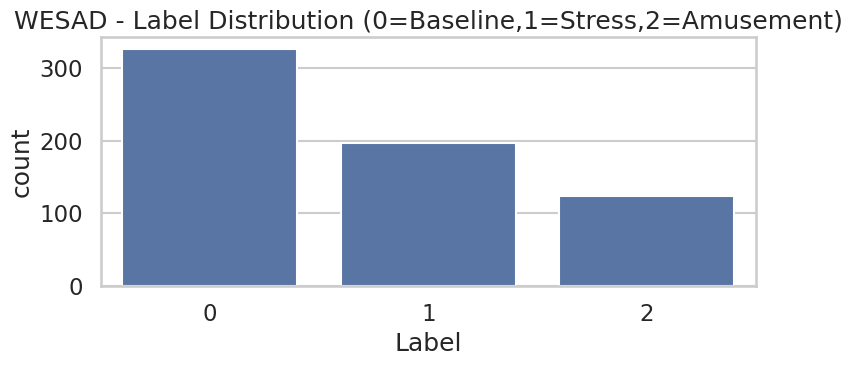

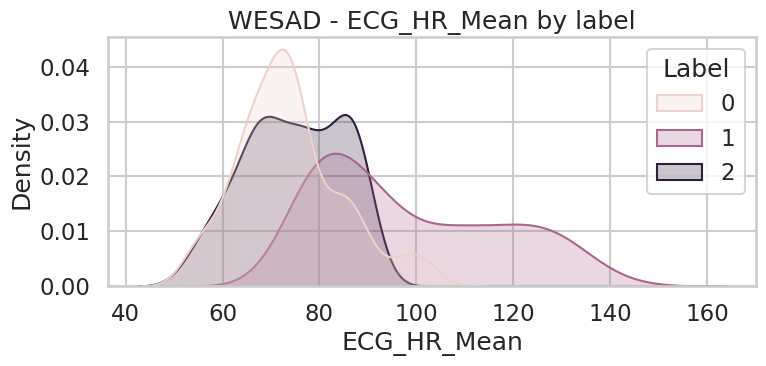

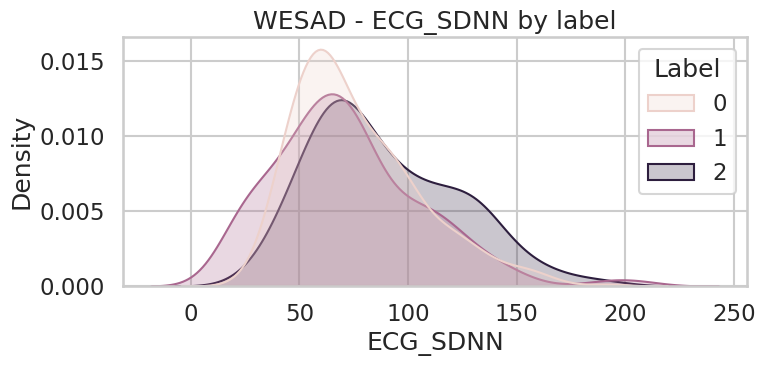

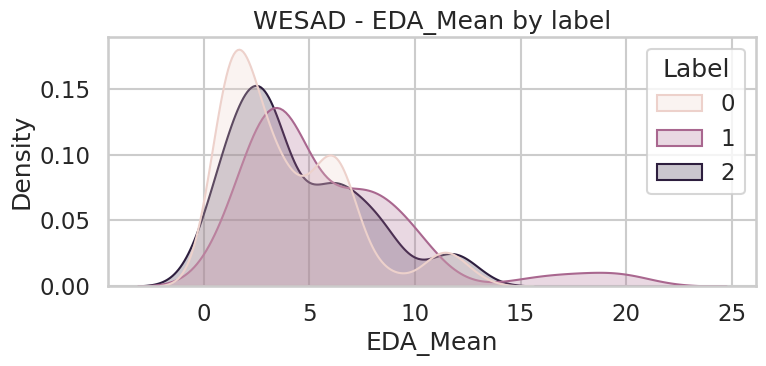

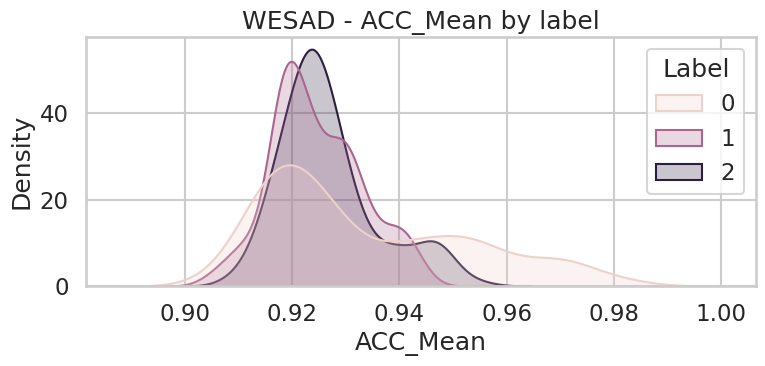

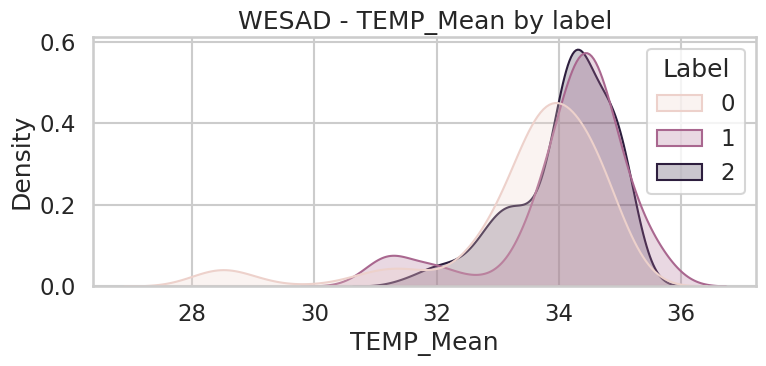

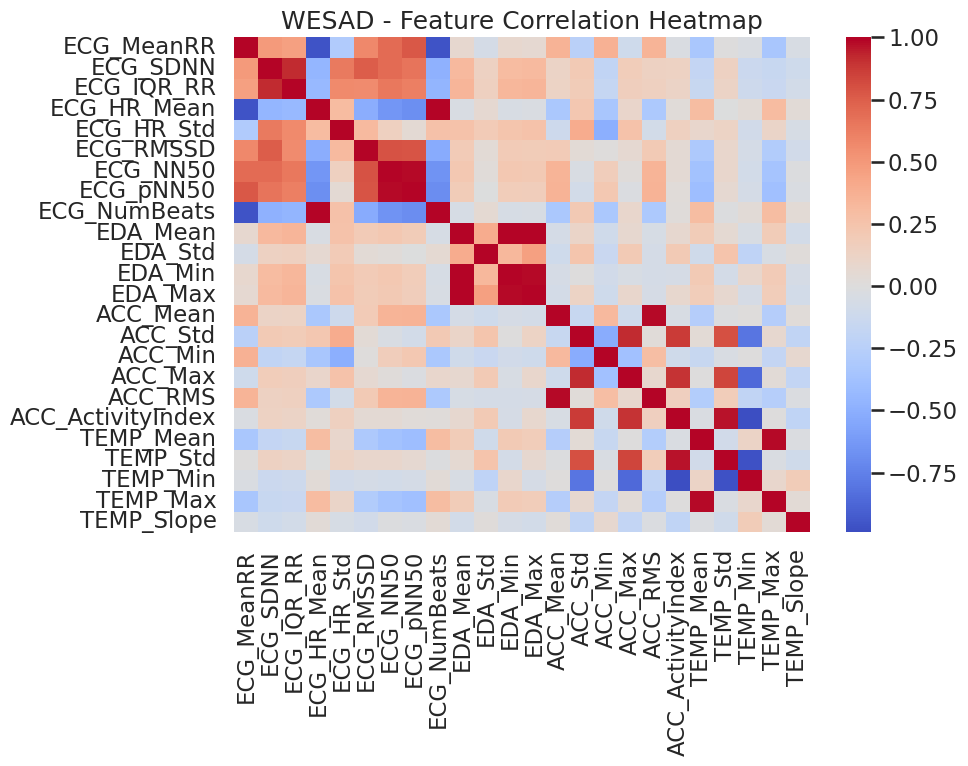

In [9]:
# ------------------------------------------------------------
# CELL B6: WESAD EDA
# ------------------------------------------------------------
if "df_all" not in globals():
    print("df_all not found. Make sure B4 & B5 ran successfully.")
else:
    plt.figure()
    sns.countplot(x=y_w)
    plt.title("WESAD - Label Distribution (0=Baseline,1=Stress,2=Amusement)")
    plt.tight_layout()
    plt.show()

    for col in ["ECG_HR_Mean", "ECG_SDNN", "EDA_Mean", "ACC_Mean", "TEMP_Mean"]:
        if col in X_w.columns:
            plt.figure()
            sns.kdeplot(
                data=df_all,
                x=col,
                hue=y_w,
                common_norm=False,
                fill=True,
            )
            plt.title(f"WESAD - {col} by label")
            plt.tight_layout()
            plt.show()

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        df_all[feature_cols_w].corr(),
        cmap="coolwarm",
        center=0,
    )
    plt.title("WESAD - Feature Correlation Heatmap")
    plt.tight_layout()
    plt.show()



=== WESAD | Dummy ===
Accuracy: 0.5
Macro F1: 0.2222222222222222
              precision    recall  f1-score   support

           0       0.50      1.00      0.67        65
           1       0.00      0.00      0.00        40
           2       0.00      0.00      0.00        25

    accuracy                           0.50       130
   macro avg       0.17      0.33      0.22       130
weighted avg       0.25      0.50      0.33       130



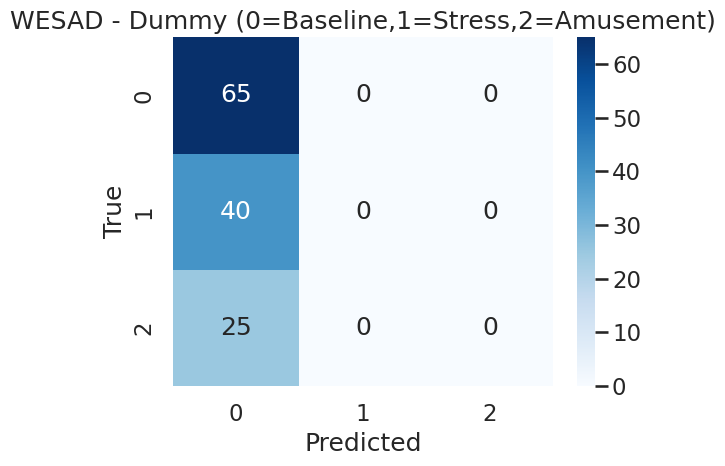


=== WESAD | LogReg ===
Accuracy: 0.7384615384615385
Macro F1: 0.6100483415765502
              precision    recall  f1-score   support

           0       0.70      0.92      0.79        65
           1       0.85      0.82      0.84        40
           2       0.60      0.12      0.20        25

    accuracy                           0.74       130
   macro avg       0.71      0.62      0.61       130
weighted avg       0.72      0.74      0.69       130



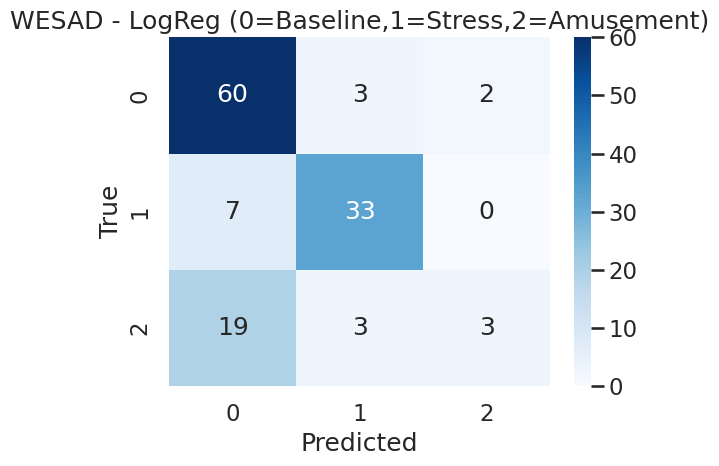


=== WESAD | KNN ===
Accuracy: 0.9230769230769231
Macro F1: 0.9059622930423963
              precision    recall  f1-score   support

           0       0.94      0.92      0.93        65
           1       0.98      1.00      0.99        40
           2       0.80      0.80      0.80        25

    accuracy                           0.92       130
   macro avg       0.90      0.91      0.91       130
weighted avg       0.92      0.92      0.92       130



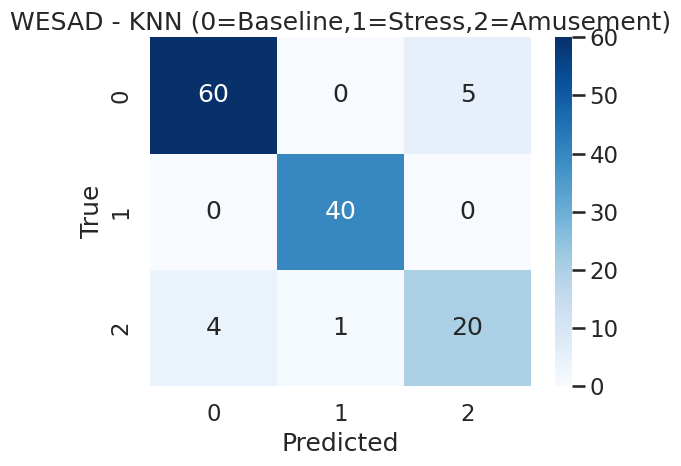


=== WESAD | SVC_RBF ===
Accuracy: 0.7615384615384615
Macro F1: 0.6606882223087911
              precision    recall  f1-score   support

           0       0.71      0.94      0.81        65
           1       0.94      0.82      0.88        40
           2       0.56      0.20      0.29        25

    accuracy                           0.76       130
   macro avg       0.74      0.65      0.66       130
weighted avg       0.75      0.76      0.73       130



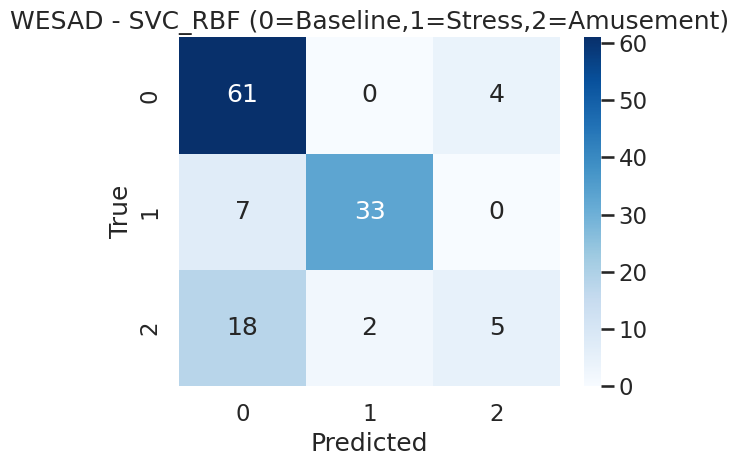


=== WESAD | RandomForest ===
Accuracy: 0.8846153846153846
Macro F1: 0.8649286987522281
              precision    recall  f1-score   support

           0       0.86      0.94      0.90        65
           1       0.93      0.93      0.93        40
           2       0.89      0.68      0.77        25

    accuracy                           0.88       130
   macro avg       0.89      0.85      0.86       130
weighted avg       0.89      0.88      0.88       130



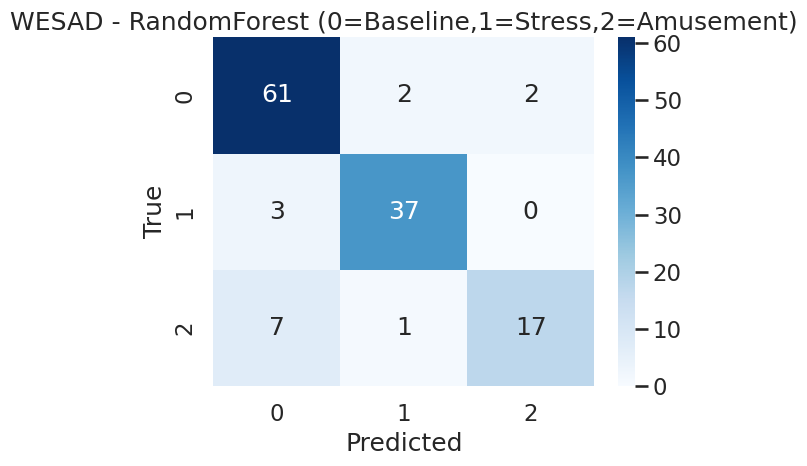


=== WESAD | GradientBoosting ===
Accuracy: 0.9153846153846154
Macro F1: 0.9104798974775333
              precision    recall  f1-score   support

           0       0.91      0.94      0.92        65
           1       0.90      0.93      0.91        40
           2       0.95      0.84      0.89        25

    accuracy                           0.92       130
   macro avg       0.92      0.90      0.91       130
weighted avg       0.92      0.92      0.92       130



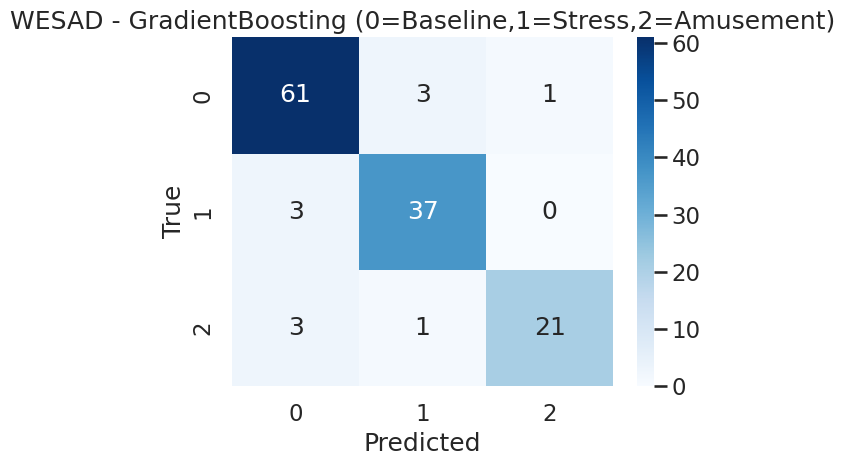


=== WESAD | MLP ===
Accuracy: 0.9307692307692308
Macro F1: 0.9209354726885554
              precision    recall  f1-score   support

           0       0.97      0.92      0.94        65
           1       0.95      0.95      0.95        40
           2       0.82      0.92      0.87        25

    accuracy                           0.93       130
   macro avg       0.91      0.93      0.92       130
weighted avg       0.93      0.93      0.93       130



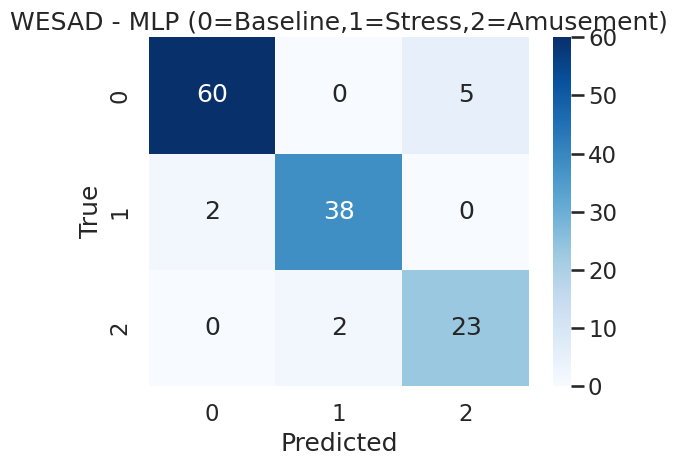


=== WESAD | XGBoost ===
Accuracy: 0.9153846153846154
Macro F1: 0.9115387845546575
              precision    recall  f1-score   support

           0       0.92      0.92      0.92        65
           1       0.90      0.93      0.91        40
           2       0.92      0.88      0.90        25

    accuracy                           0.92       130
   macro avg       0.91      0.91      0.91       130
weighted avg       0.92      0.92      0.92       130



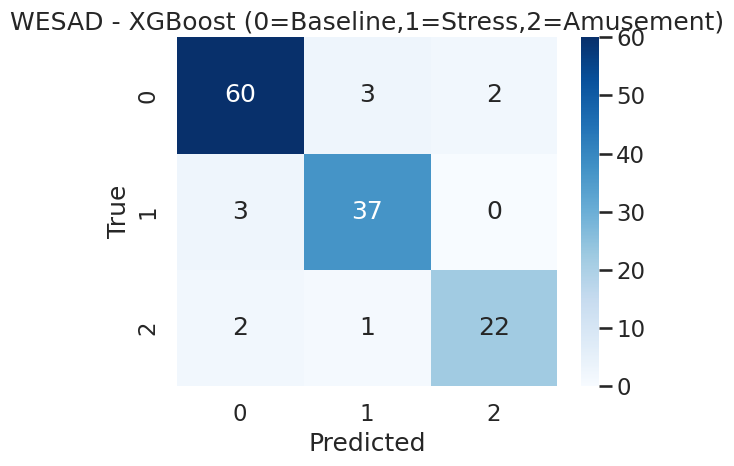


=== WESAD - Model Comparison ===


,model,accuracy,macro_f1
6,MLP,0.930769,0.920935
2,KNN,0.923077,0.905962
5,GradientBoosting,0.915385,0.910480
7,XGBoost,0.915385,0.911539
4,RandomForest,0.884615,0.864929
3,SVC_RBF,0.761538,0.660688
1,LogReg,0.738462,0.610048
0,Dummy,0.500000,0.222222


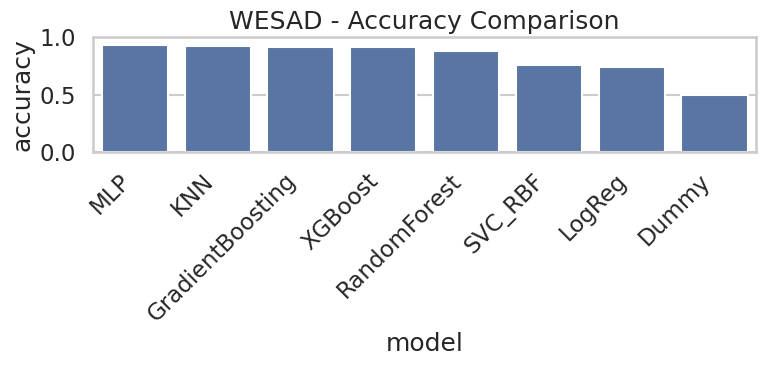

In [10]:
# ------------------------------------------------------------
# CELL B7: Supervised classification - WESAD
# ------------------------------------------------------------
if "df_all" not in globals():
    print("df_all not found. Make sure previous cells ran successfully.")
else:
    scaler_w = StandardScaler()
    X_w_scaled = scaler_w.fit_transform(X_w)

    Xw_train, Xw_test, yw_train, yw_test = train_test_split(
        X_w_scaled,
        y_w,
        test_size=0.2,
        random_state=RNG,
        stratify=y_w,
    )

    models_w = {
        "Dummy": DummyClassifier(strategy="most_frequent"),
        "LogReg": LogisticRegression(
            max_iter=1000,
            multi_class="multinomial",
        ),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "SVC_RBF": SVC(kernel="rbf", probability=True),
        "RandomForest": RandomForestClassifier(
            n_estimators=250,
            max_depth=18,
            random_state=RNG,
            n_jobs=-1,
        ),
        "GradientBoosting": GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=RNG,
        ),
        "MLP": MLPClassifier(
            hidden_layer_sizes=(64, 32),
            max_iter=400,
            random_state=RNG,
        ),
        "XGBoost": xgb.XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="multi:softprob",
            num_class=3,
            eval_metric="mlogloss",
            tree_method="hist",
            random_state=RNG,
        ),
    }

    results_w = []

    for name, model in models_w.items():
        print(f"\n=== WESAD | {name} ===")
        model.fit(Xw_train, yw_train)
        y_pred = model.predict(Xw_test)

        acc = accuracy_score(yw_test, y_pred)
        macro_f1 = f1_score(yw_test, y_pred, average="macro")

        print("Accuracy:", acc)
        print("Macro F1:", macro_f1)
        print(classification_report(yw_test, y_pred))

        plot_cm(
            yw_test,
            y_pred,
            labels=[0, 1, 2],
            title=f"WESAD - {name} (0=Baseline,1=Stress,2=Amusement)",
        )

        results_w.append(
            {"model": name, "accuracy": acc, "macro_f1": macro_f1}
        )

    results_w_df = pd.DataFrame(results_w).sort_values(
        "accuracy", ascending=False
    )
    print("\n=== WESAD - Model Comparison ===")
    display(results_w_df)

    plt.figure(figsize=(8, 4))
    sns.barplot(data=results_w_df, x="model", y="accuracy")
    plt.ylim(0, 1)
    plt.title("WESAD - Accuracy Comparison")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()



WESAD feature groups:
ECG: ['ECG_MeanRR', 'ECG_SDNN', 'ECG_IQR_RR', 'ECG_HR_Mean', 'ECG_HR_Std', 'ECG_RMSSD', 'ECG_NN50', 'ECG_pNN50', 'ECG_NumBeats']
EDA: ['EDA_Mean', 'EDA_Std', 'EDA_Min', 'EDA_Max']
ACC: ['ACC_Mean', 'ACC_Std', 'ACC_Min', 'ACC_Max', 'ACC_RMS', 'ACC_ActivityIndex']
TEMP: ['TEMP_Mean', 'TEMP_Std', 'TEMP_Min', 'TEMP_Max', 'TEMP_Slope']

=== Evaluating WESAD group: ECG_only (n_features=9) ===

=== Evaluating WESAD group: EDA_only (n_features=4) ===

=== Evaluating WESAD group: ACC_only (n_features=6) ===

=== Evaluating WESAD group: TEMP_only (n_features=5) ===

=== Evaluating WESAD group: ALL_modalities (n_features=24) ===

=== WESAD - Accuracy per feature group & model ===


,Group,n_features,Dummy_acc,LogReg_acc,RF_acc,XGB_acc
0,ECG_only,9,0.5,0.653846,0.746154,0.753846
1,EDA_only,4,0.5,0.584615,0.738462,0.738462
2,ACC_only,6,0.5,0.561538,0.623077,0.653846
3,TEMP_only,5,0.5,0.561538,0.692308,0.738462
4,ALL_modalities,24,0.5,0.738462,0.884615,0.923077


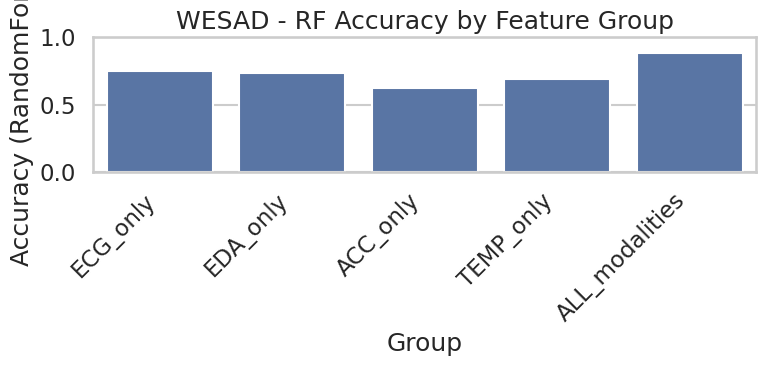

In [11]:
# ------------------------------------------------------------
# CELL B8: Feature group analysis
# ------------------------------------------------------------
if "df_all" not in globals():
    print("df_all not found. Make sure previous cells ran successfully.")
else:
    ecg_cols = [c for c in feature_cols_w if c.startswith("ECG_")]
    eda_cols = [c for c in feature_cols_w if c.startswith("EDA_")]
    acc_cols = [c for c in feature_cols_w if c.startswith("ACC_")]
    temp_cols = [c for c in feature_cols_w if c.startswith("TEMP_")]

    print("\nWESAD feature groups:")
    print("ECG:", ecg_cols)
    print("EDA:", eda_cols)
    print("ACC:", acc_cols)
    print("TEMP:", temp_cols)

    def evaluate_on_feature_set(feature_names, X_full, y_full, random_state=42):
        feature_names = [f for f in feature_names if f in X_full.columns]
        if len(feature_names) == 0:
            return None

        X_sub = X_full[feature_names].copy()
        num_cols_sub = X_sub.select_dtypes(include=[np.number]).columns
        X_sub[num_cols_sub] = X_sub[num_cols_sub].fillna(
            X_sub[num_cols_sub].median()
        )

        scaler_local = StandardScaler()
        X_scaled_sub = scaler_local.fit_transform(X_sub)

        X_tr, X_te, y_tr, y_te = train_test_split(
            X_scaled_sub,
            y_full,
            test_size=0.2,
            random_state=random_state,
            stratify=y_full,
        )

        local_models = {
            "Dummy": DummyClassifier(strategy="most_frequent"),
            "LogReg": LogisticRegression(
                max_iter=500,
                multi_class="multinomial",
            ),
            "RF": RandomForestClassifier(
                n_estimators=200,
                max_depth=15,
                random_state=random_state,
                n_jobs=-1,
            ),
            "XGB": xgb.XGBClassifier(
                n_estimators=200,
                max_depth=4,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="multi:softprob",
                num_class=3,
                eval_metric="mlogloss",
                tree_method="hist",
                random_state=random_state,
            ),
        }

        res = {"n_features": len(feature_names)}
        for mname, mdl in local_models.items():
            mdl.fit(X_tr, y_tr)
            y_pred_sub = mdl.predict(X_te)
            res[f"{mname}_acc"] = accuracy_score(y_te, y_pred_sub)

        return res

    feature_groups = {
        "ECG_only": ecg_cols,
        "EDA_only": eda_cols,
        "ACC_only": acc_cols,
        "TEMP_only": temp_cols,
        "ALL_modalities": feature_cols_w,
    }

    group_results = []
    for gname, cols in feature_groups.items():
        print(
            f"\n=== Evaluating WESAD group: {gname} (n_features={len(cols)}) ==="
        )
        res = evaluate_on_feature_set(cols, X_w, y_w, random_state=RNG)
        if res is not None:
            res["Group"] = gname
            group_results.append(res)

    df_group_results = pd.DataFrame(group_results)
    df_group_results = df_group_results[
        ["Group", "n_features", "Dummy_acc", "LogReg_acc", "RF_acc", "XGB_acc"]
    ]
    print("\n=== WESAD - Accuracy per feature group & model ===")
    display(df_group_results)

    plt.figure(figsize=(8, 4))
    sns.barplot(data=df_group_results, x="Group", y="RF_acc")
    plt.ylim(0, 1)
    plt.ylabel("Accuracy (RandomForest)")
    plt.title("WESAD - RF Accuracy by Feature Group")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


Best WESAD tree model: XGBoost


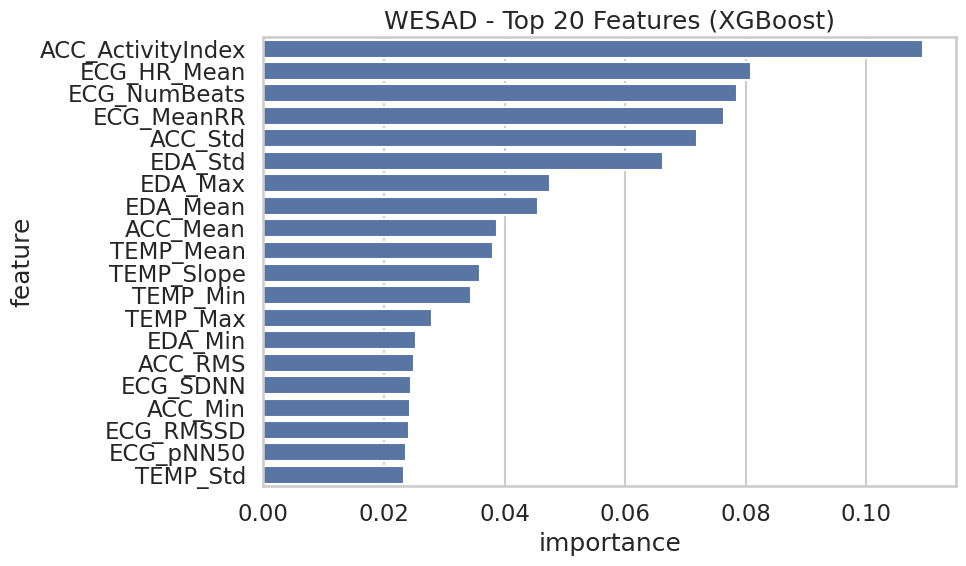

In [12]:
# ------------------------------------------------------------
# CELL B9: Feature importance - best tree model (WESAD)
# ------------------------------------------------------------
if "df_all" not in globals():
    print("df_all not found. Make sure previous cells ran successfully.")
else:
    best_tree_name_w = results_w_df[
        results_w_df["model"].isin(["RandomForest", "XGBoost"])
    ].sort_values("accuracy", ascending=False)["model"].iloc[0]

    print("Best WESAD tree model:", best_tree_name_w)
    best_tree_w = models_w[best_tree_name_w]

    importances_w = best_tree_w.feature_importances_
    fi_w = pd.DataFrame(
        {"feature": feature_cols_w, "importance": importances_w}
    ).sort_values("importance", ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=fi_w.head(20), x="importance", y="feature")
    plt.title(f"WESAD - Top 20 Features ({best_tree_name_w})")
    plt.tight_layout()
    plt.show()



Autoencoder data shapes:
Baseline+Stress windows: 523
Baseline-only windows: 326

=== Training Autoencoder (Baseline only) ===
Epoch 01/20 - loss: 0.786221
Epoch 02/20 - loss: 0.763967
Epoch 03/20 - loss: 0.736321
Epoch 04/20 - loss: 0.700637
Epoch 05/20 - loss: 0.654931
Epoch 06/20 - loss: 0.594187
Epoch 07/20 - loss: 0.533024
Epoch 08/20 - loss: 0.478974
Epoch 09/20 - loss: 0.434334
Epoch 10/20 - loss: 0.397553
Epoch 11/20 - loss: 0.372346
Epoch 12/20 - loss: 0.347825
Epoch 13/20 - loss: 0.318763
Epoch 14/20 - loss: 0.292901
Epoch 15/20 - loss: 0.265189
Epoch 16/20 - loss: 0.240140
Epoch 17/20 - loss: 0.211552
Epoch 18/20 - loss: 0.187104
Epoch 19/20 - loss: 0.167637
Epoch 20/20 - loss: 0.151608

AE threshold (95th percentile of baseline error): 0.40173677

=== AE Stress Anomaly Detection (Baseline vs Stress) ===
              precision    recall  f1-score   support

      Normal       0.79      0.95      0.86       326
  StressAnom       0.87      0.58      0.70       197

    accu

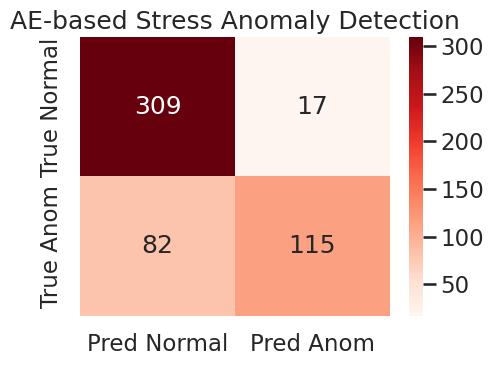

AE ROC-AUC (reconstruction error as score): 0.8640808445703965


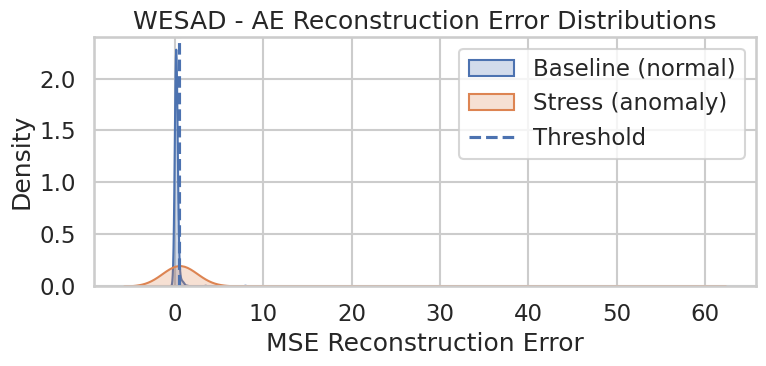


=== PIPELINE DONE ===
- Sports vitals: EDA + models + feature importance
- WESAD: multi-sensor features, models, feature groups, AE anomaly detection


In [13]:
# ------------------------------------------------------------
# CELL B10: Autoencoder anomaly detection (Baseline vs Stress)
# ------------------------------------------------------------
if "df_all" not in globals():
    print("df_all not found. Make sure previous cells ran successfully.")
else:
    # Use only classes 0 (Baseline) and 1 (Stress)
    mask_bs = y_w.isin([0, 1])
    X_bs = X_w_scaled[mask_bs]
    y_bs = y_w[mask_bs].values  # 0 = baseline, 1 = stress

    # Train AE only on baseline windows
    normal_mask = (y_bs == 0)
    X_normal = X_bs[normal_mask]

    print("\nAutoencoder data shapes:")
    print("Baseline+Stress windows:", X_bs.shape[0])
    print("Baseline-only windows:", X_normal.shape[0])

    class Autoencoder(nn.Module):
        def __init__(self, input_dim, latent_dim=16):
            super().__init__()
            self.encoder = nn.Sequential(
                nn.Linear(input_dim, 64),
                nn.ReLU(),
                nn.Linear(64, latent_dim),
                nn.ReLU(),
            )
            self.decoder = nn.Sequential(
                nn.Linear(latent_dim, 64),
                nn.ReLU(),
                nn.Linear(64, input_dim),
            )

        def forward(self, x):
            z = self.encoder(x)
            x_rec = self.decoder(z)
            return x_rec

    input_dim = X_normal.shape[1]
    ae = Autoencoder(input_dim=input_dim, latent_dim=16).to(device)

    tensor_X_normal = torch.tensor(X_normal, dtype=torch.float32)
    train_dataset_ae = TensorDataset(tensor_X_normal)
    train_loader_ae = DataLoader(train_dataset_ae, batch_size=64, shuffle=True)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(ae.parameters(), lr=1e-3)
    EPOCHS_AE = 20

    print("\n=== Training Autoencoder (Baseline only) ===")
    ae.train()
    for epoch in range(1, EPOCHS_AE + 1):
        epoch_loss = 0.0
        for (batch_X,) in train_loader_ae:
            batch_X = batch_X.to(device)
            optimizer.zero_grad()
            recon = ae(batch_X)
            loss = criterion(recon, batch_X)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * batch_X.size(0)
        epoch_loss /= len(train_dataset_ae)
        print(f"Epoch {epoch:02d}/{EPOCHS_AE} - loss: {epoch_loss:.6f}")

    # Evaluate reconstruction errors on Baseline+Stress
    ae.eval()
    with torch.no_grad():
        X_all_torch = torch.tensor(X_bs, dtype=torch.float32).to(device)
        X_rec_all = ae(X_all_torch)
        recon_errors = torch.mean(
            (X_rec_all - X_all_torch) ** 2, dim=1
        ).cpu().numpy()

    baseline_errors = recon_errors[y_bs == 0]
    threshold = np.percentile(baseline_errors, 95)
    print("\nAE threshold (95th percentile of baseline error):", threshold)

    y_pred_anom = (recon_errors > threshold).astype(int)  # 1 = anomaly
    y_true_anom = (y_bs == 1).astype(int)  # 1 = stress

    print(
        "\n=== AE Stress Anomaly Detection (Baseline vs Stress) ==="
    )
    print(
        classification_report(
            y_true_anom, y_pred_anom, target_names=["Normal", "StressAnom"]
        )
    )

    cm_ae = confusion_matrix(y_true_anom, y_pred_anom)
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm_ae,
        annot=True,
        fmt="d",
        cmap="Reds",
        xticklabels=["Pred Normal", "Pred Anom"],
        yticklabels=["True Normal", "True Anom"],
    )
    plt.title("AE-based Stress Anomaly Detection")
    plt.tight_layout()
    plt.show()

    auc_ae = roc_auc_score(y_true_anom, recon_errors)
    print("AE ROC-AUC (reconstruction error as score):", auc_ae)

    plt.figure(figsize=(8, 4))
    sns.kdeplot(baseline_errors, label="Baseline (normal)", fill=True)
    sns.kdeplot(
        recon_errors[y_bs == 1],
        label="Stress (anomaly)",
        fill=True,
    )
    plt.axvline(threshold, linestyle="--", label="Threshold")
    plt.title("WESAD - AE Reconstruction Error Distributions")
    plt.xlabel("MSE Reconstruction Error")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("\n=== PIPELINE DONE ===")
    print("- Sports vitals: EDA + models + feature importance")
    print("- WESAD: multi-sensor features, models, feature groups, AE anomaly detection")


In [14]:
# ------------------------------------------------------------
# CELL B11: Inspect best models & do quick CV
# ------------------------------------------------------------
from sklearn.model_selection import cross_val_score, StratifiedKFold

print("Model ranking on WESAD:")
display(results_w_df)

# Choose candidates (if they exist)
candidates = [m for m in ["XGBoost", "RandomForest", "SVC_RBF", "MLP"] if m in results_w_df["model"].values]
print("Candidates for tuning:", candidates)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)

for name in candidates:
    mdl = models_w[name]
    scores = cross_val_score(mdl, X_w_scaled, y_w, cv=cv, scoring="accuracy", n_jobs=-1)
    print(f"\n{name} 5-fold CV accuracy: {scores.mean():.4f} ± {scores.std():.4f}")


Model ranking on WESAD:


,model,accuracy,macro_f1
6,MLP,0.930769,0.920935
2,KNN,0.923077,0.905962
5,GradientBoosting,0.915385,0.910480
7,XGBoost,0.915385,0.911539
4,RandomForest,0.884615,0.864929
3,SVC_RBF,0.761538,0.660688
1,LogReg,0.738462,0.610048
0,Dummy,0.500000,0.222222


Candidates for tuning: ['XGBoost', 'RandomForest', 'SVC_RBF', 'MLP']

XGBoost 5-fold CV accuracy: 0.9459 ± 0.0147

RandomForest 5-fold CV accuracy: 0.9258 ± 0.0242

SVC_RBF 5-fold CV accuracy: 0.8083 ± 0.0218

MLP 5-fold CV accuracy: 0.9304 ± 0.0240


Fitting 3 folds for each of 48 candidates, totalling 144 fits

Best RF params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}
Best RF CV accuracy: 0.6368288831467126

TUNED RandomForest performance on test set:
Accuracy: 0.8846153846153846
Macro F1: 0.8649286987522281
              precision    recall  f1-score   support

           0       0.86      0.94      0.90        65
           1       0.93      0.93      0.93        40
           2       0.89      0.68      0.77        25

    accuracy                           0.88       130
   macro avg       0.89      0.85      0.86       130
weighted avg       0.89      0.88      0.88       130



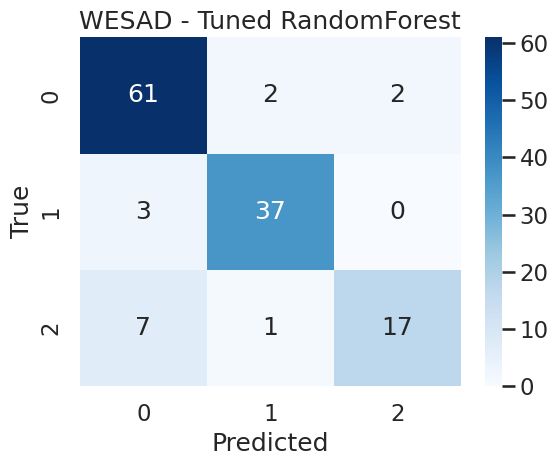

In [15]:
# ------------------------------------------------------------
# CELL B12: Hyperparameter tuning - RandomForest
# ------------------------------------------------------------
from sklearn.model_selection import GridSearchCV

if "RandomForest" not in models_w:
    print("RandomForest model not found.")
else:
    rf_base = RandomForestClassifier(random_state=RNG, n_jobs=-1)

    rf_param_grid = {
        "n_estimators": [200, 400],
        "max_depth": [10, 18, None],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2],
        "max_features": ["sqrt", "log2"],
    }

    rf_grid = GridSearchCV(
        rf_base,
        rf_param_grid,
        scoring="accuracy",
        n_jobs=-1,
        cv=3,
        verbose=1,
    )

    rf_grid.fit(X_w_scaled, y_w)

    print("\nBest RF params:", rf_grid.best_params_)
    print("Best RF CV accuracy:", rf_grid.best_score_)

    # Evaluate tuned RF on the original train/test split
    rf_best = rf_grid.best_estimator_
    rf_best.fit(Xw_train, yw_train)
    y_pred_rf = rf_best.predict(Xw_test)

    print("\nTUNED RandomForest performance on test set:")
    print("Accuracy:", accuracy_score(yw_test, y_pred_rf))
    print("Macro F1:", f1_score(yw_test, y_pred_rf, average="macro"))
    print(classification_report(yw_test, y_pred_rf))

    plot_cm(
        yw_test,
        y_pred_rf,
        labels=[0, 1, 2],
        title="WESAD - Tuned RandomForest",
    )


Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best XGB params: {'subsample': 0.9, 'reg_lambda': 2.0, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 1.0, 'colsample_bytree': 0.8}
Best XGB CV accuracy: 0.698585989089865

TUNED XGBoost performance on test set:
Accuracy: 0.8384615384615385
Macro F1: 0.7858631436944691
              precision    recall  f1-score   support

           0       0.81      0.94      0.87        65
           1       0.86      0.93      0.89        40
           2       0.92      0.44      0.59        25

    accuracy                           0.84       130
   macro avg       0.86      0.77      0.79       130
weighted avg       0.85      0.84      0.82       130



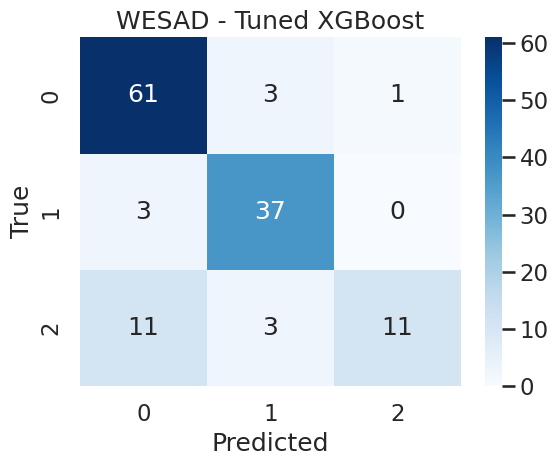

In [16]:
# ------------------------------------------------------------
# CELL B13: Hyperparameter tuning - XGBoost
# ------------------------------------------------------------
from sklearn.model_selection import RandomizedSearchCV

if "XGBoost" not in models_w:
    print("XGBoost model not found.")
else:
    xgb_base = xgb.XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        tree_method="hist",
        random_state=RNG,
        n_jobs=-1,
    )

    xgb_param_dist = {
        "n_estimators": [200, 300, 400],
        "max_depth": [3, 4, 5],
        "learning_rate": [0.01, 0.05, 0.1],
        "subsample": [0.7, 0.8, 0.9, 1.0],
        "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
        "gamma": [0, 0.5, 1.0],
        "reg_lambda": [1.0, 2.0, 5.0],
    }

    xgb_rand = RandomizedSearchCV(
        xgb_base,
        param_distributions=xgb_param_dist,
        n_iter=20,              # you can increase for better search
        scoring="accuracy",
        n_jobs=-1,
        cv=3,
        verbose=1,
        random_state=RNG,
    )

    xgb_rand.fit(X_w_scaled, y_w)

    print("\nBest XGB params:", xgb_rand.best_params_)
    print("Best XGB CV accuracy:", xgb_rand.best_score_)

    xgb_best = xgb_rand.best_estimator_
    xgb_best.fit(Xw_train, yw_train)
    y_pred_xgb = xgb_best.predict(Xw_test)

    print("\nTUNED XGBoost performance on test set:")
    print("Accuracy:", accuracy_score(yw_test, y_pred_xgb))
    print("Macro F1:", f1_score(yw_test, y_pred_xgb, average="macro"))
    print(classification_report(yw_test, y_pred_xgb))

    plot_cm(
        yw_test,
        y_pred_xgb,
        labels=[0, 1, 2],
        title="WESAD - Tuned XGBoost",
    )
